---
title: "Volatility Forecast (Part 4: Clustering and HAR)"
date: 2026-03-02
description: "We establish the heterogeneous autoregressive (HAR) model as a baseline for log-realized-variance forecasting, documenting the long-memory structure of daily equity volatility."
categories: [Quantitative Finance, Volatility Modeling, Time Series]
format:
  html:
    toc: true
    code-fold: true
execute:
  echo: true
  warning: false
  message: false
  freeze: false
---

## Motivation

Volatility clustering---the tendency for large (small) price moves to follow large (small) price moves---is one of the most robust stylized facts in financial markets. The autocorrelation function (ACF) of squared or absolute returns decays slowly, suggesting long memory. The Heterogeneous Autoregressive (HAR) model of Corsi (2009) captures this long-memory behaviour parsimoniously by regressing future log-realized variance on daily, weekly, and monthly averages of past log-realized variance. Despite its simplicity, HAR remains a standard benchmark in the volatility-forecasting literature.

In this post we fit the HAR model to SPY daily data and ask a pointed question: *does multi-horizon averaging add genuine conditional forecasting power, or does it merely exploit the mean-reversion that any unconditional average would capture?* We document the ACF structure of log-realized variance, estimate HAR by OLS, and evaluate out-of-sample performance against both a persistence baseline and the unconditional training-set mean. This sets the stage for Part 5, where we introduce regime-clustering extensions.

In [12]:
#| echo: false
#| output: false

import sys
import os
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

# --- PATH SETUP ---
WORKSPACE_ROOT = Path("/Users/steveyang/Projects/Github")
BLOG_PATH = WORKSPACE_ROOT / "steveya.github.io"
VF_PATH = WORKSPACE_ROOT / "volatility-forecast"
AF_PATH = WORKSPACE_ROOT / "alphaforge"

for p in (BLOG_PATH, VF_PATH, AF_PATH):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

load_dotenv(VF_PATH / ".env")
logging.basicConfig(level=logging.ERROR)

# --- LIBRARY IMPORTS ---
from alphaforge.data.cache import FileCacheBackend
from alphaforge.data.query import Query
from volatility_forecast.pipeline import build_default_ctx
from volatility_forecast.sources import TiingoEODSource

from blog_styles import (
    style_results_table, inject_blog_table_css,
    apply_blog_plot_style, BLOG_PALETTE,
)

# --- CONSTANTS ---
TICKER = "SPY"
START  = "2010-01-01"
END    = "2025-12-31"

# --- STYLES ---
inject_blog_table_css()
apply_blog_plot_style()

# --- DATA CONTEXT ---
cache = FileCacheBackend(Path(os.environ.get("TIINGO_CACHE_DIR", ".af_cache")))
ctx = build_default_ctx(
    tiingo_api_key=os.environ.get("TIINGO_API") or os.environ.get("TIINGO_API_KEY"),
    tiingo_cache_backends=[cache],
    tiingo_cache_mode="use",
)

## Data

We load daily adjusted OHLCV data for SPY from Tiingo via the `alphaforge` / `volatility_forecast` data pipeline, the same infrastructure used in Parts 1--3. Log returns are computed from adjusted close prices.

In [13]:
def load_daily_ohlcv(
    ticker: str,
    start: str = "2010-01-01",
    end: str = "2025-12-31",
) -> pd.DataFrame:
    """
    Load daily OHLCV via the volatility_forecast Tiingo source.

    Returns a DataFrame indexed by date (tz-naive DatetimeIndex) with columns:
    open, high, low, adj_close, volume.
    """
    query = Query(
        table="market.ohlcv",
        columns=["open", "high", "low", "close", "volume"],
        start=pd.Timestamp(start, tz="UTC"),
        end=pd.Timestamp(end, tz="UTC"),
        entities=[ticker.upper()],
    )
    panel = ctx.fetch_panel("tiingo", query)
    df = panel.df

    # Normalize: the Tiingo source maps adjClose → close when use_adjusted=True
    # so 'close' already contains adjusted prices.
    df = df.rename(columns={"close": "adj_close"})
    df = df.drop(columns=["asof_utc"], errors="ignore")

    # Flatten multi-index → date-only index
    if isinstance(df.index, pd.MultiIndex):
        df = df.droplevel("entity_id")
    df.index = pd.DatetimeIndex(df.index.date, name="date")
    df = df.sort_index()
    df = df[~df.index.duplicated(keep="first")]
    return df

ohlcv = load_daily_ohlcv(TICKER, START, END)
print(f"{TICKER}: {len(ohlcv)} trading days, {ohlcv.index[0].date()} to {ohlcv.index[-1].date()}")
ohlcv.tail(3)

SPY: 4023 trading days, 2010-01-04 to 2025-12-30


,open,high,low,adj_close,volume
date,,,,,
2025-12-26,690.640,691.660,689.27,690.31,41613347
2025-12-29,687.540,689.200,686.07,687.85,62559503
2025-12-30,687.445,688.555,686.58,687.01,47160671


## Method

### Realized variance proxy

We use the squared daily log return as a proxy for realized variance:

$$
r_t = \log(P_t / P_{t-1}), \qquad RV_t = r_t^2
$$

To reduce the extreme right skew of $RV_t$, we work in the log domain:

$$
y_t = \log(RV_t + \epsilon), \qquad \epsilon = 10^{-12}
$$

### HAR model

The heterogeneous autoregressive (HAR) model of Corsi (2009) captures long-memory structure by regressing on three horizons:

$$
y_{t+1} = \beta_0 + \beta_1 \, y_t + \beta_5 \, \bar{y}_{t}^{(5)} + \beta_{22} \, \bar{y}_{t}^{(22)} + \varepsilon_{t+1}
$$

where $\bar{y}_{t}^{(h)} = \frac{1}{h}\sum_{j=0}^{h-1} y_{t-j}$ is the rolling mean of log-realized variance over the past $h$ days. The three regressors correspond to daily, weekly, and monthly trader horizons.

In [14]:
#| label: feature-engineering
#| code-fold: true
#| code-summary: "Feature engineering"

# --- Log returns and realized variance ---
prices = ohlcv["adj_close"]
log_returns = np.log(prices / prices.shift(1))
rv = log_returns ** 2
y = np.log(rv + 1e-12)

# --- HAR features (aligned at time t, no look-ahead) ---
x1 = y.copy()                                # daily
x5 = y.rolling(5, min_periods=5).mean()       # weekly
x22 = y.rolling(22, min_periods=22).mean()    # monthly

# --- Target: next-day log-RV ---
y_target = y.shift(-1)

# --- Assemble and drop NaNs ---
har_df = pd.DataFrame({
    "y": y,
    "x1": x1,
    "x5": x5,
    "x22": x22,
    "y_target": y_target,
}, index=ohlcv.index)
har_df = har_df.dropna()

print(f"HAR dataset: {len(har_df)} rows, {har_df.index[0].date()} to {har_df.index[-1].date()}")

HAR dataset: 4000 rows, 2010-02-04 to 2025-12-29


## Exploratory analysis

### Log-realized variance time series

The plot below shows $y_t = \log(r_t^2 + \epsilon)$ over time. Volatility clustering is clearly visible: calm periods (2013--2015, 2017--2019) alternate with sharp spikes around macro events (2011 debt ceiling, 2015 China deval, 2018 volmageddon, 2020 COVID, 2022 rate hikes).

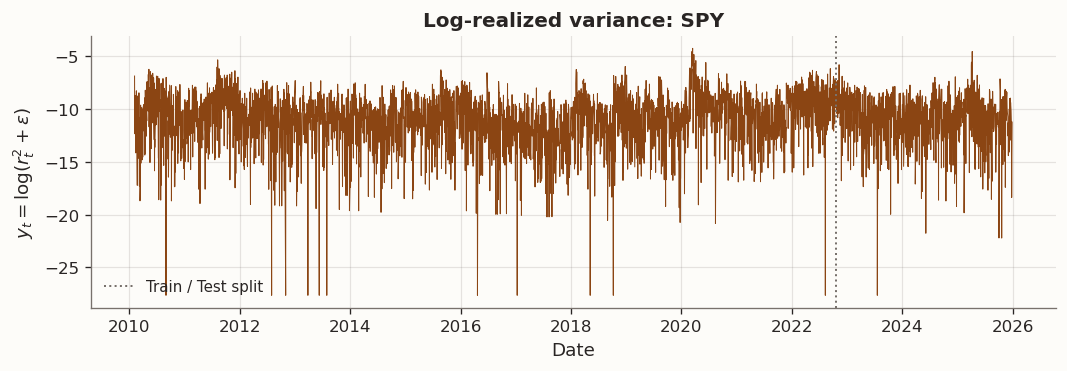

In [15]:
#| label: fig-log-rv
#| fig-cap: "Log-realized variance of SPY daily returns"

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(har_df.index, har_df["y"], lw=0.6, color=BLOG_PALETTE[0])

# Train / test split marker (n_train defined later; use 80% of dataset)
split_idx = har_df.index[int(len(har_df) * 0.8)]
ax.axvline(split_idx, color=BLOG_PALETTE[3], ls=":", lw=1.2, label="Train / Test split")

ax.set_ylabel("$y_t = \\log(r_t^2 + \\epsilon)$")
ax.set_xlabel("Date")
ax.set_title("Log-realized variance: SPY")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

### Autocorrelation function

The ACF of $y_t$ quantifies the persistence of volatility at different horizons. A slow, hyperbolic decay---rather than a sharp exponential cutoff---is the signature of long memory and motivates the multi-horizon structure of HAR.

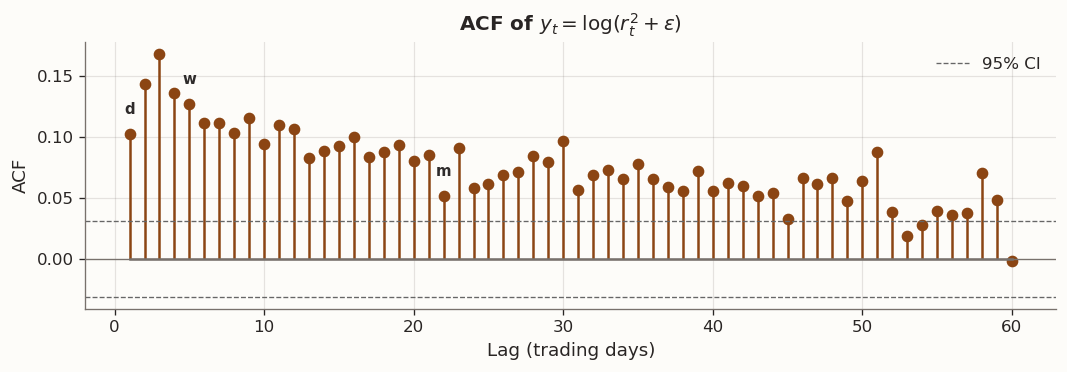

ACF at lag 1: 0.103
ACF at lag 5: 0.127
ACF at lag 22: 0.052
ACF at lag 60: -0.002


In [16]:
#| label: fig-acf
#| fig-cap: "ACF of log-realized variance, lags 1--60"

from statsmodels.tsa.stattools import acf

MAX_LAGS = 60
acf_vals = acf(har_df["y"].values, nlags=MAX_LAGS, fft=True)

fig, ax = plt.subplots(figsize=(9, 3.2))
lags = np.arange(1, MAX_LAGS + 1)
ax.stem(lags, acf_vals[1:], linefmt=BLOG_PALETTE[0], markerfmt="o",
        basefmt=BLOG_PALETTE[3])
ax.axhline(0, color=BLOG_PALETTE[3], lw=0.8)

# Approximate 95% confidence band
n = len(har_df)
ax.axhline(1.96 / np.sqrt(n), ls="--", color=BLOG_PALETTE[4], lw=0.8, label="95% CI")
ax.axhline(-1.96 / np.sqrt(n), ls="--", color=BLOG_PALETTE[4], lw=0.8)

# Annotate HAR horizons
for lag, label in [(1, "d"), (5, "w"), (22, "m")]:
    ax.annotate(label, (lag, acf_vals[lag]), textcoords="offset points",
                xytext=(0, 12), ha="center", fontsize=9, fontweight="bold",
                color=BLOG_PALETTE[2])

ax.set_xlabel("Lag (trading days)")
ax.set_ylabel("ACF")
ax.set_title("ACF of $y_t = \\log(r_t^2 + \\epsilon)$")
ax.legend()
fig.tight_layout()
plt.show()

print(f"ACF at lag 1: {acf_vals[1]:.3f}")
print(f"ACF at lag 5: {acf_vals[5]:.3f}")
print(f"ACF at lag 22: {acf_vals[22]:.3f}")
print(f"ACF at lag 60: {acf_vals[60]:.3f}")

## HAR model: estimation and evaluation

We split the data chronologically---first 80% for training, last 20% for out-of-sample testing---and fit the HAR model by OLS. The baseline forecast is naive persistence: $\hat{y}_{t+1} = y_t$.

In [17]:
#| label: har-fit
#| code-fold: true
#| code-summary: "HAR OLS estimation"

import statsmodels.api as sm

# --- Train / test split (80/20 chronological) ---
n_total = len(har_df)
n_train = int(n_total * 0.8)
train = har_df.iloc[:n_train]
test = har_df.iloc[n_train:]

print(f"Train: {len(train)} rows ({train.index[0].date()} to {train.index[-1].date()})")
print(f"Test:  {len(test)} rows  ({test.index[0].date()} to {test.index[-1].date()})")

# --- Fit HAR by OLS with HC3-robust standard errors ---
X_train = sm.add_constant(train[["x1", "x5", "x22"]])
X_test = sm.add_constant(test[["x1", "x5", "x22"]])

har_model = sm.OLS(train["y_target"], X_train).fit(cov_type="HC3")
print("\n", har_model.summary2())

Train: 3200 rows (2010-02-04 to 2022-10-19)
Test:  800 rows  (2022-10-20 to 2025-12-29)

                   Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.090     
Dependent Variable: y_target         AIC:                15113.4620
Date:               2026-03-02 18:18 BIC:                15137.7456
No. Observations:   3200             Log-Likelihood:     -7552.7   
Df Model:           3                F-statistic:        105.4     
Df Residuals:       3196             Prob (F-statistic): 4.74e-65  
R-squared:          0.091            Scale:              6.5787    
---------------------------------------------------------------------
             Coef.    Std.Err.      z      P>|z|     [0.025    0.975]
---------------------------------------------------------------------
const       -3.4379     0.4549   -7.5579   0.0000   -4.3294   -2.5464
x1          -0.0396     0.0200   -1.9816   0.0475   -0.0788   -0.0004
x5           0.2974     0.0475    

In [18]:
#| label: oos-evaluation
#| code-fold: true
#| code-summary: "Out-of-sample evaluation"

# --- OOS predictions ---
pred_har = har_model.predict(X_test)
pred_persist = test["x1"].values               # persistence: y_{t+1} = y_t
pred_mean = np.full_like(actual := test["y_target"].values,
                         train["y"].mean())     # unconditional mean

# --- OOS metrics ---
mse_har     = np.mean((actual - pred_har) ** 2)
mse_persist = np.mean((actual - pred_persist) ** 2)
mse_mean    = np.mean((actual - pred_mean) ** 2)
oos_r2_persist = 1.0 - mse_har / mse_persist
oos_r2_mean    = 1.0 - mse_har / mse_mean
corr = np.corrcoef(pred_har, actual)[0, 1]

metrics = pd.DataFrame({
    "Metric": [
        "MSE (HAR)",
        "MSE (Persistence)",
        "MSE (Unconditional mean)",
        "OOS R² vs Persistence",
        "OOS R² vs Mean",
        "Corr(pred, actual)",
    ],
    "Out-of-Sample": [
        f"{mse_har:.4f}",
        f"{mse_persist:.4f}",
        f"{mse_mean:.4f}",
        f"{oos_r2_persist:.4f}",
        f"{oos_r2_mean:.4f}",
        f"{corr:.4f}",
    ],
})
display(style_results_table(metrics, precision=4, index_col="Metric"))

,Out-of-Sample
Metric,
MSE (HAR),6.1234
MSE (Persistence),12.5232
MSE (Unconditional mean),6.2453
OOS R² vs Persistence,0.5110
OOS R² vs Mean,0.0195
"Corr(pred, actual)",0.1575


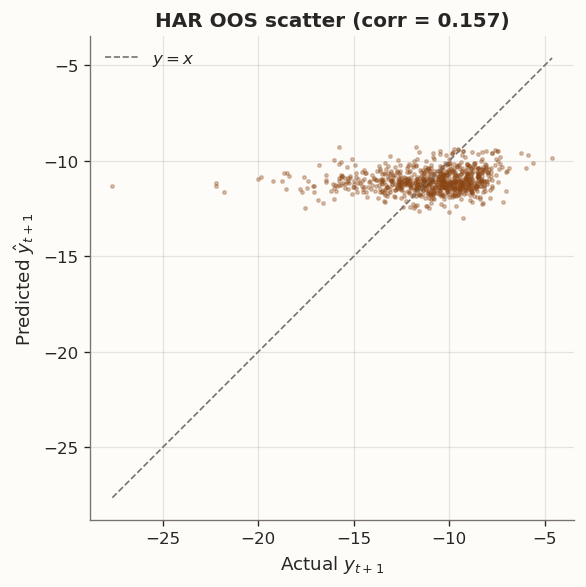

In [19]:
#| label: fig-scatter
#| fig-cap: "HAR out-of-sample predictions vs actuals"

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(actual, pred_har, s=4, alpha=0.3, color=BLOG_PALETTE[0], rasterized=True)
lims = [min(actual.min(), pred_har.min()), max(actual.max(), pred_har.max())]
ax.plot(lims, lims, ls="--", lw=1.0, color=BLOG_PALETTE[3], label="$y = x$")
ax.set_xlabel("Actual $y_{t+1}$")
ax.set_ylabel("Predicted $\\hat{y}_{t+1}$")
ax.set_title(f"HAR OOS scatter (corr = {corr:.3f})")
ax.legend()
ax.set_aspect("equal", adjustable="box")
fig.tight_layout()
plt.show()

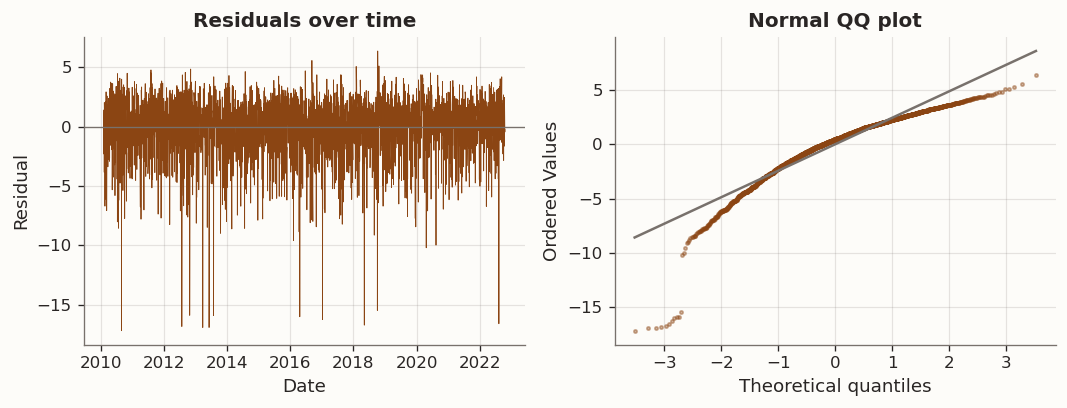

Durbin-Watson: 2.002  |  Skew: -1.607  |  Excess kurtosis: 5.780


In [24]:
#| label: fig-residuals
#| fig-cap: "Residual diagnostics: time series and QQ plot"
#| code-fold: true
#| code-summary: "Residual diagnostics"

from scipy import stats as sp_stats

resid = har_model.resid

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

# Residual time series
axes[0].plot(train.index, resid, lw=0.5, color=BLOG_PALETTE[0])
axes[0].axhline(0, color=BLOG_PALETTE[3], lw=0.8)
axes[0].set_title("Residuals over time")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Residual")

# QQ plot
sp_stats.probplot(resid, dist="norm", plot=axes[1])
axes[1].get_lines()[0].set(color=BLOG_PALETTE[0], markersize=2, alpha=0.4)
axes[1].get_lines()[1].set(color=BLOG_PALETTE[3])
axes[1].set_title("Normal QQ plot")

fig.tight_layout()
plt.show()

from statsmodels.stats.stattools import durbin_watson
dw = durbin_watson(resid)
print(f"Durbin-Watson: {dw:.3f}  |  Skew: {resid.skew():.3f}  |  Excess kurtosis: {resid.kurtosis():.3f}")

## Results

### Coefficient estimates

The weekly ($x_5$) and monthly ($x_{22}$) HAR regressors are highly significant (HC3-robust SEs), while the daily component ($x_1$) is marginally insignificant ($p \approx 0.05$). The coefficient magnitudes reveal how information at different horizons contributes to the next-day forecast:

- The **monthly** component ($x_{22} \approx 0.43$) carries the largest coefficient, anchoring the forecast toward the longer-run volatility level.
- The **weekly** component ($x_5 \approx 0.30$) captures intermediate mean-reversion dynamics.
- The **daily** component ($x_1 \approx -0.04$) is small and marginally insignificant, suggesting that once weekly and monthly averages are included, the previous day adds little incremental information. The negative sign is a collinearity artifact---it does not mean higher daily volatility predicts *lower* volatility tomorrow.

The sum of the three slope coefficients is roughly 0.7, indicating that log-RV is persistent but mean-reverting rather than a near-unit-root process.

### Horizons of information

The coefficient pattern maps onto a market-microstructure story about *who moves volatility*:

- $\hat\beta_1 \approx 0$ (**fast traders / overnight flow**): once weekly and monthly averages are conditioned on, the marginal day's squared return adds no signal---intraday noise dominates.
- $\hat\beta_5 \approx 0.30$ (**weekly rebalancers / systematic strategies**): captures intermediate-horizon mean-reversion from portfolio rebalancing clusters, options expiry cycles, and weekly fund flows.
- $\hat\beta_{22} \approx 0.43$ (**slow macro uncertainty**): the dominant coefficient, reflecting information that moves on monthly time scales---central bank cycles, earnings seasons, geopolitical repricing.

**Caveat:** these individual coefficients are unstable because the three regressors share lagged observations ($\text{corr}(x_5, x_{22}) \approx 0.70$, condition number $\approx$ 197). The negative sign on $\hat\beta_1$ is a partial-effect artifact, not a causal claim.

### Out-of-sample performance

Against the persistence baseline ($\hat y_{t+1} = y_t$), HAR achieves an OOS $R^2 \approx 0.51$. However, persistence is an unusually weak benchmark for this mean-reverting series---it has 2$\times$ the MSE of simply predicting the training-set mean. Against the unconditional mean, HAR's OOS $R^2$ is only $\approx 0.02$: the model adds almost nothing beyond knowing the long-run average.

The scatter plot confirms this: predictions cluster tightly in a narrow band near the unconditional mean, with little ability to track extreme volatility events. The OOS correlation ($\approx 0.16$) is positive but modest.

## Interpretation

1. **ACF shape → long memory.** The ACF of $y_t$ decays slowly---remaining significantly positive out to roughly lag 59---characteristic of long-memory processes. This hyperbolic decay is inconsistent with low-order ARMA models and motivates the multi-scale HAR specification. Formally, HAR approximates the infinite AR representation of a fractionally integrated process using three "box-car" averaging kernels at daily, weekly, and monthly horizons.

2. **Why HAR "works" (and why it barely beats the mean).** The monthly component dominates ($\hat\beta_{22} \approx 0.43$), meaning HAR's forecasting power comes primarily from knowing the *slow-moving average level* of log-RV. This is almost exactly what the unconditional mean provides---hence OOS $R^2$ vs mean $\approx 0.02$. HAR's large $R^2$ vs persistence ($0.51$) merely reflects that persistence is a terrible baseline for a mean-reverting series: predicting "today's value again" ignores the strong pull toward the long-run average.

3. **Residual diagnostics.** The Durbin-Watson statistic ($\approx 2.0$) confirms negligible residual autocorrelation at lag 1, validating the 1-step-ahead OLS setup. However, the QQ plot reveals heavy left tails (kurtosis $\approx 5.8$, skew $\approx -1.6$): extreme negative log-RV surprises (i.e., days of unexpectedly *low* volatility following a noisy period) are poorly modeled. HC3-robust standard errors partially address this for inference; for forecasting, it motivates regime-switching extensions (Part 5).

## Caveats

- **Noisy proxy.** Squared daily returns are a very noisy estimator of true latent variance. High-frequency realized variance (e.g., 5-minute RV) or range-based proxies (Parkinson, Garman--Klass) would provide a cleaner target but require intraday data or careful handling of overnight gaps.
- **Structural breaks.** The 2010--2025 sample spans several distinct volatility regimes (post-GFC calm, 2020 COVID shock, 2022 rate-hiking cycle). A single OLS fit assumes parameter stability across all of these.
- **Multicollinearity, not serial correlation.** The weekly and monthly rolling means share lagged observations, inflating regressor multicollinearity (condition number $\approx$ 197). For multi-step HAR variants that predict *averaged* future RV, overlapping targets would also induce residual autocorrelation requiring Newey-West SEs. In the 1-step-ahead specification used here, the target $y_{t+1}$ is non-overlapping and the Durbin-Watson statistic (2.00) confirms negligible residual autocorrelation; nevertheless, HC3-robust standard errors account for the heavy-tailed residuals (kurtosis $\approx$ 5.8).
- **Log-domain vs level-domain.** Working in log-RV simplifies the regression but complicates interpretation of forecast errors in variance units. Exponentiated predictions $\exp(\hat{y}_{t+1})$ are biased estimators of $RV_{t+1}$ due to Jensen's inequality.
- **Single asset.** Results are shown for SPY only. Whether HAR's relative performance holds across asset classes (FX, rates, commodities) and market-cap segments is an empirical question.
- **No asymmetry.** The standard HAR model treats positive and negative returns symmetrically. Leverage effects---volatility rising more after negative returns---are well documented and motivate extensions (HAR-J, LHAR) that we plan to address in Part 5.

## Robustness: expanding-window refit

A single 80/20 split gives one snapshot of OOS performance. To check whether results are stable across regimes, we refit HAR on an expanding training window, evaluating on non-overlapping 250-day blocks. We track both the rolling OOS $R^2$ (vs unconditional mean) and the coefficient trajectories over time.

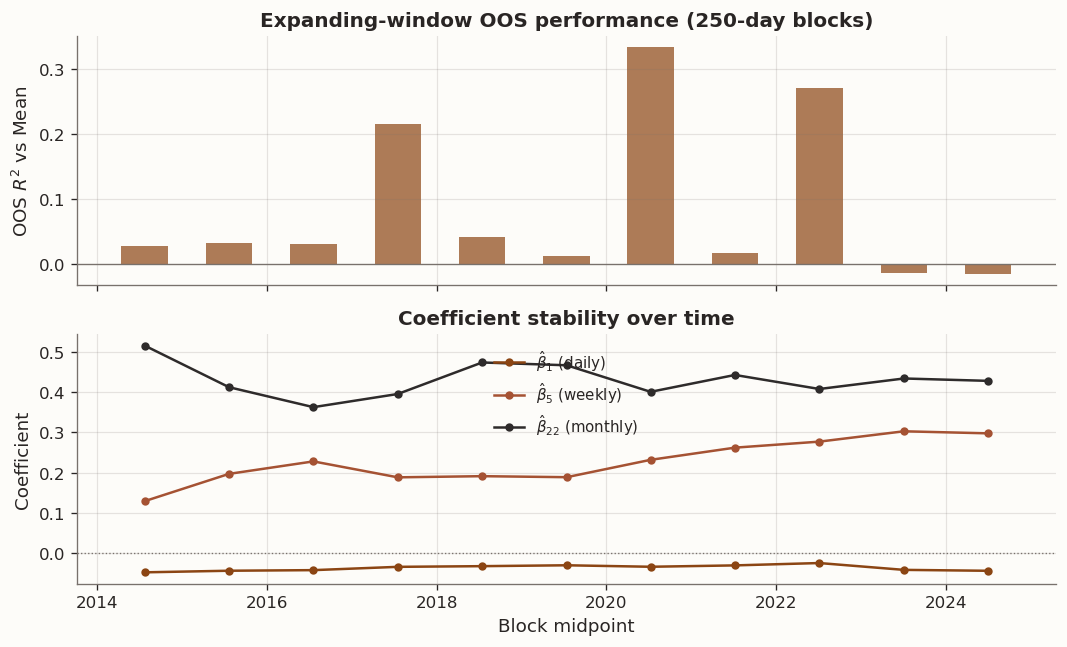

In [21]:
#| label: fig-expanding-window
#| fig-cap: "Expanding-window OOS R² and coefficient stability"
#| code-fold: true
#| code-summary: "Expanding-window refit"

BLOCK = 250  # evaluation block size (≈1 year)
MIN_TRAIN = 1000  # minimum training observations

ew_results = []
for end_train in range(MIN_TRAIN, n_total - BLOCK, BLOCK):
    tr = har_df.iloc[:end_train]
    te = har_df.iloc[end_train : end_train + BLOCK]

    Xtr = sm.add_constant(tr[["x1", "x5", "x22"]])
    Xte = sm.add_constant(te[["x1", "x5", "x22"]])

    m = sm.OLS(tr["y_target"], Xtr).fit()
    pred = m.predict(Xte)
    act = te["y_target"].values
    pred_mn = np.full_like(act, tr["y"].mean())

    mse_m = np.mean((act - pred) ** 2)
    mse_mn = np.mean((act - pred_mn) ** 2)

    ew_results.append({
        "mid_date": te.index[len(te) // 2],
        "oos_r2_mean": 1.0 - mse_m / mse_mn,
        "beta_1": m.params["x1"],
        "beta_5": m.params["x5"],
        "beta_22": m.params["x22"],
    })

ew_df = pd.DataFrame(ew_results)

fig, axes = plt.subplots(2, 1, figsize=(9, 5.5), sharex=True)

# Panel 1: rolling OOS R²
axes[0].bar(ew_df["mid_date"], ew_df["oos_r2_mean"], width=200,
            color=BLOG_PALETTE[0], alpha=0.7, edgecolor="none")
axes[0].axhline(0, color=BLOG_PALETTE[3], lw=0.8)
axes[0].set_ylabel("OOS $R^2$ vs Mean")
axes[0].set_title("Expanding-window OOS performance (250-day blocks)")

# Panel 2: coefficient trajectories
for col, label, c in [("beta_1", r"$\hat\beta_1$ (daily)", BLOG_PALETTE[0]),
                       ("beta_5", r"$\hat\beta_5$ (weekly)", BLOG_PALETTE[1]),
                       ("beta_22", r"$\hat\beta_{22}$ (monthly)", BLOG_PALETTE[2])]:
    axes[1].plot(ew_df["mid_date"], ew_df[col], marker="o", ms=4, label=label, color=c)
axes[1].axhline(0, color=BLOG_PALETTE[3], lw=0.8, ls=":")
axes[1].set_ylabel("Coefficient")
axes[1].set_xlabel("Block midpoint")
axes[1].set_title("Coefficient stability over time")
axes[1].legend(fontsize=9)

fig.tight_layout()
plt.show()

## Mathematical perspective

The HAR model is a **constrained VAR(22)** in disguise: instead of fitting 22 free AR coefficients, it projects $y_{t+1}$ onto a 3-dimensional subspace spanned by box-car averages over windows of length 1, 5, and 22. This is a form of dimensional reduction via pre-specified aggregation kernels---trading bias for variance reduction (3 parameters instead of 22). The restriction is motivated by Müller et al.'s (1997) heterogeneous-market hypothesis, which posits that traders operating at different frequencies imprint autocorrelation at distinct time scales.

Mathematically, the slow hyperbolic decay of the ACF (consistent with fractional integration parameter $d \approx 0.3$--$0.4$) implies that no finite-order ARMA model can capture the dynamics efficiently. HAR approximates the infinite AR representation of this long-memory process,

$$
y_{t+1} = \sum_{k=1}^{\infty} \pi_k \, y_{t+1-k} + \varepsilon_{t+1}, \qquad \pi_k \sim C \cdot k^{d-1},
$$

with a parsimonious 3-point quadrature: $\pi_k$ constant within $\{1\}, \{2,\dots,5\}, \{6,\dots,22\}$ and zero beyond. The estimated coefficients reveal that longer-scale macro uncertainty ($\hat\beta_{22} \approx 0.43$) dominates, with the daily lag contributing near-zero marginal information.

### Long-memory verification: Hurst exponent

If log-RV is truly long-memory, the ACF should decay as $\rho(k) \sim C \cdot k^{2d-1}$ for large $k$. We estimate the fractional integration parameter $d$ from the log-log regression of the ACF on lag, and report the Hurst exponent $H = d + 0.5$.

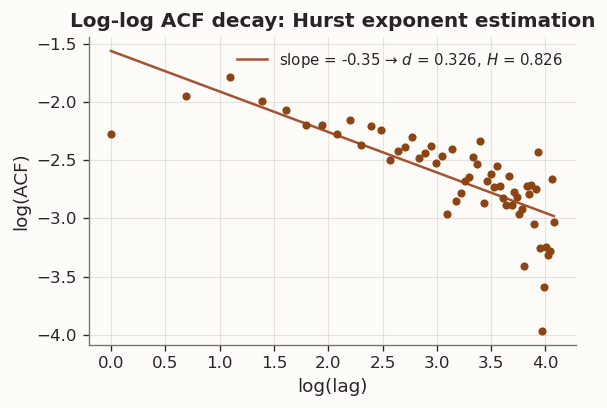

Estimated fractional integration d = 0.326
Hurst exponent H = 0.826
H > 0.5 confirms long memory


In [22]:
#| label: hurst-estimate
#| code-fold: true
#| code-summary: "Hurst exponent estimation"

# Log-log regression of ACF on lag to estimate fractional integration d
acf_lags = np.arange(1, MAX_LAGS + 1)
valid = acf_vals[1:MAX_LAGS + 1] > 0  # only positive ACF values
log_k = np.log(acf_lags[valid])
log_acf = np.log(acf_vals[1:MAX_LAGS + 1][valid])

slope, intercept = np.polyfit(log_k, log_acf, 1)
d_hat = (slope + 1) / 2  # fractional integration parameter
H_hat = d_hat + 0.5      # Hurst exponent

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.scatter(log_k, log_acf, s=15, color=BLOG_PALETTE[0], zorder=3)
fit_x = np.linspace(log_k.min(), log_k.max(), 100)
ax.plot(fit_x, slope * fit_x + intercept, color=BLOG_PALETTE[1], lw=1.5,
        label=f"slope = {slope:.2f} → $d$ = {d_hat:.3f}, $H$ = {H_hat:.3f}")
ax.set_xlabel("log(lag)")
ax.set_ylabel("log(ACF)")
ax.set_title("Log-log ACF decay: Hurst exponent estimation")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

print(f"Estimated fractional integration d = {d_hat:.3f}")
print(f"Hurst exponent H = {H_hat:.3f}")
print(f"H > 0.5 confirms long memory" if H_hat > 0.5 else "H ≤ 0.5: no long memory detected")

### Specialization tests: do slower horizons matter?

Two natural restrictions test whether the multi-horizon structure adds value:

1. **AR(1) specialization** ($\beta_5 = \beta_{22} = 0$): only yesterday's log-RV matters---no horizon heterogeneity.
2. **Equal-weight specialization** ($\beta_1 = \beta_5 = \beta_{22}$): all horizons contribute equally---no dominant time scale.

We compare via AIC and OOS MSE.

In [23]:
#| label: specialization-tests
#| code-fold: true
#| code-summary: "AR(1) and equal-weight specialization tests"

# --- AR(1): only daily lag ---
har_ar1 = sm.OLS(train["y_target"], sm.add_constant(train[["x1"]])).fit()
pred_ar1 = har_ar1.predict(sm.add_constant(test[["x1"]]))
mse_ar1 = np.mean((actual - pred_ar1) ** 2)

# --- Equal-weight: single combined regressor ---
har_df["x_equal"] = (har_df["x1"] + har_df["x5"] + har_df["x22"]) / 3
train_eq = har_df.iloc[:n_train]
test_eq = har_df.iloc[n_train:]
har_eq = sm.OLS(train_eq["y_target"], sm.add_constant(train_eq[["x_equal"]])).fit()
pred_eq = har_eq.predict(sm.add_constant(test_eq[["x_equal"]]))
mse_eq = np.mean((actual - pred_eq) ** 2)

# --- Summary table ---
pred_mn = np.full_like(actual, train["y"].mean())
mse_mn = np.mean((actual - pred_mn) ** 2)

spec_df = pd.DataFrame({
    "Model": ["HAR (full)", "AR(1) only", "Equal-weight", "Unconditional mean"],
    "AIC": [f"{har_model.aic:.1f}", f"{har_ar1.aic:.1f}", f"{har_eq.aic:.1f}", "—"],
    "OOS MSE": [f"{mse_har:.4f}", f"{mse_ar1:.4f}", f"{mse_eq:.4f}", f"{mse_mn:.4f}"],
    "OOS R² vs Mean": [
        f"{1 - mse_har/mse_mn:.4f}",
        f"{1 - mse_ar1/mse_mn:.4f}",
        f"{1 - mse_eq/mse_mn:.4f}",
        "0.0000",
    ],
})
display(style_results_table(spec_df, precision=4, index_col="Model"))

,AIC,OOS MSE,OOS R² vs Mean
Model,,,
HAR (full),15113.5,6.1234,0.0195
AR(1) only,15362.3,6.3486,-0.0165
Equal-weight,15229.3,6.3398,-0.0151
Unconditional mean,—,6.2453,0.0000


## Summary

The HAR model does three things well: it formalises the long-memory structure of realised volatility ($H \approx 0.83$), it beats the persistence baseline decisively (OOS $R^2 \approx 0.51$), and it does so with only three interpretable parameters. But the honest takeaway is that most of that performance comes from mean-reversion---predicting the training-set average gets you 98% of the way there. The model's conditional edge (OOS $R^2$ vs mean $\approx 0.02$) is real but thin, and the specialization tests confirm that the multi-horizon decomposition matters: both AR(1)-only and equal-weight restrictions lose to the unconditional mean.

This sets up a clear agenda for **Part 5**: the residual QQ plot reveals heavy-tailed surprises the linear model cannot capture. Regime-switching extensions (Markov-switching HAR, threshold HAR) or incorporating the leverage effect should give the model something the unconditional mean cannot---the ability to track volatility regimes in real time.

## Extension: HAR → STES / XGBoost-STES

Parts 1--3 of this series introduced Smooth Transition Exponential Smoothing (STES) and its XGBoost extension (XGB-STES) as flexible variance filters where the update rate $\alpha_t$ adapts to market conditions via a gate function $\alpha_t = \sigma(X_t \beta)$. Here we integrate those methods with the HAR baseline and ask two questions:

1. **Feature fusion.** Does adding HAR's multi-horizon features ($x_1, x_5, x_{22}$) to the STES/XGB-STES gate function improve variance forecasts?
2. **Residual learning.** Can STES/XGB-STES capture structure in HAR's prediction errors?

### Domain mismatch

An important architectural constraint: STES and XGB-STES predict **variance in level domain** via the exponential smoothing recursion $v_{t+1} = \alpha_t r_t^2 + (1 - \alpha_t) v_t$, where $v_{t+1} \geq 0$ by construction. HAR predicts **log-RV**. To compare on the same target ($y_{t+1}$), we wrap STES/XGB-STES output: $\hat{y} = \log(\hat{v} + \epsilon)$.

For residual learning, the EWMA recursion's non-negativity constraint means it *cannot* produce negative output, while HAR's log-domain residuals are signed (mean $\approx 0$). We fit the models on the residual target anyway; the results illustrate why architecture-aware fusion matters.

In [25]:
#| label: stes-extension-fit
#| code-fold: true
#| code-summary: "STES / XGB-STES: model fitting"

from sklearn.preprocessing import StandardScaler
from volatility_forecast.model.stes_model import STESModel
from volatility_forecast.model.tree_stes_model import XGBoostSTESModel

EPS = 1e-12

# ── 1. Prepare STES dataset aligned to har_df ─────────────────────────
# Returns at time t (drives the EWMA recursion via r_t^2)
returns_aligned = log_returns.reindex(har_df.index)

# Variance-domain target: r_{t+1}^2 ≈ exp(y_target)
# (since y_target = log(r_{t+1}^2 + eps))
y_var = np.exp(har_df["y_target"])

# STES features at time t: const, r_t, |r_t|, r_t^2
stes_feats = pd.DataFrame({
    "const": 1.0,
    "r": returns_aligned.values,
    "abs_r": returns_aligned.abs().values,
    "r_sq": (returns_aligned ** 2).values,
}, index=har_df.index)

# Feature-fusion features: STES base + HAR horizons
fusion_feats = stes_feats.copy()
fusion_feats["x1"]  = har_df["x1"].values
fusion_feats["x5"]  = har_df["x5"].values
fusion_feats["x22"] = har_df["x22"].values

# ── 2. Train / test split (same boundary as HAR) ──────────────────────
stes_tr, stes_te = stes_feats.iloc[:n_train], stes_feats.iloc[n_train:]
fus_tr,  fus_te  = fusion_feats.iloc[:n_train], fusion_feats.iloc[n_train:]
yv_tr,   yv_te   = y_var.iloc[:n_train],  y_var.iloc[n_train:]
r_tr,    r_te    = returns_aligned.iloc[:n_train], returns_aligned.iloc[n_train:]

# HAR in-sample fitted values and log-domain residual (no leakage: HAR fit on train only)
yhat_har_train_is = har_model.predict(X_train)          # fitted values on train
resid_train = train["y_target"].values - yhat_har_train_is.values  # signed residual

# ── 3. Feature scaling (fit on train only) ─────────────────────────────
def scale_features(df_train, df_test):
    """StandardScale non-const columns (fit on train, apply to both)."""
    scaler = StandardScaler()
    cols = [c for c in df_train.columns if c != "const"]
    tr, te = df_train.copy(), df_test.copy()
    tr[cols] = scaler.fit_transform(df_train[cols])
    te[cols] = scaler.transform(df_test[cols])
    return tr, te

stes_tr_s, stes_te_s = scale_features(stes_tr, stes_te)
fus_tr_s,  fus_te_s  = scale_features(fus_tr,  fus_te)

# ── 4. Fit / predict helper ───────────────────────────────────────────
def fit_predict_var(model, X_tr, X_te, y_tr, r_tr, r_te):
    """Fit on train, predict on [train+test] with warm-start, return test variance."""
    model.fit(X_tr, y_tr, returns=r_tr)
    # Warm-start: run recursion through entire train→test series, slice test tail
    X_all = pd.concat([X_tr, X_te])
    r_all = pd.concat([r_tr, r_te])
    v_all = np.asarray(model.predict(X_all, returns=r_all))
    return v_all[len(X_tr):]

# ── 5. XGB-STES config (matches Parts 2–3: linear booster, alternating fit) ──
XGB_PARAMS = {
    "booster": "gblinear", "updater": "coord_descent",
    "learning_rate": 0.01, "reg_lambda": 1.0, "verbosity": 0,
}
XGB_ROUNDS = 200

# ── 6. Fit all models ─────────────────────────────────────────────────
models_log = {}  # name → test-set predictions in LOG domain

# (A) STES baseline — variance domain, features: const + r, |r|, r²
stes_base = STESModel(random_state=42)
v = fit_predict_var(stes_base, stes_tr_s, stes_te_s, yv_tr, r_tr, r_te)
models_log["STES"] = np.log(np.maximum(v, EPS))

# (B) XGB-STES baseline
xgb_base = XGBoostSTESModel(
    xgb_params=XGB_PARAMS, num_boost_round=XGB_ROUNDS,
    fit_method="alternating", random_state=42,
)
v = fit_predict_var(xgb_base, stes_tr_s, stes_te_s, yv_tr, r_tr, r_te)
models_log["XGB-STES"] = np.log(np.maximum(v, EPS))

# (C) STES + HAR features
stes_fus = STESModel(random_state=42)
v = fit_predict_var(stes_fus, fus_tr_s, fus_te_s, yv_tr, r_tr, r_te)
models_log["STES + HAR feat"] = np.log(np.maximum(v, EPS))

# (D) XGB-STES + HAR features
xgb_fus = XGBoostSTESModel(
    xgb_params=XGB_PARAMS, num_boost_round=XGB_ROUNDS,
    fit_method="alternating", random_state=42,
)
v = fit_predict_var(xgb_fus, fus_tr_s, fus_te_s, yv_tr, r_tr, r_te)
models_log["XGB-STES + HAR feat"] = np.log(np.maximum(v, EPS))

# (E) HAR + STES residual
#     Architecture note: EWMA output v ≥ 0, but residuals are signed → domain mismatch.
#     The combined prediction will have a systematic upward bias.
stes_resid = STESModel(random_state=42)
v_resid = fit_predict_var(stes_resid, stes_tr_s, stes_te_s,
                          pd.Series(resid_train, index=stes_tr.index),
                          r_tr, r_te)
models_log["HAR + STES resid"] = pred_har.values + v_resid

# (F) HAR + XGB-STES residual
xgb_resid = XGBoostSTESModel(
    xgb_params=XGB_PARAMS, num_boost_round=XGB_ROUNDS,
    fit_method="alternating", random_state=42,
)
v_resid = fit_predict_var(xgb_resid, stes_tr_s, stes_te_s,
                          pd.Series(resid_train, index=stes_tr.index),
                          r_tr, r_te)
models_log["HAR + XGB resid"] = pred_har.values + v_resid

# Add HAR itself for comparison
models_log["HAR"] = pred_har.values

print(f"Fitted {len(models_log)} models on {len(r_tr)} train / {len(r_te)} test days")

Fitted 7 models on 3200 train / 800 test days


In [27]:
#| label: stes-comparison-table
#| code-fold: true
#| code-summary: "Comparison table"

y_test_actual = test["y_target"].values
train_mean_y  = train["y_target"].mean()          # unconditional mean baseline
mse_mean_baseline = np.mean((y_test_actual - train_mean_y) ** 2)

def evaluate(y_true, y_pred):
    """MSE, OOS R² vs unconditional mean, correlation."""
    mse = float(np.mean((y_true - y_pred) ** 2))
    r2  = 1.0 - mse / mse_mean_baseline
    c   = float(np.corrcoef(y_true, y_pred)[0, 1])
    return mse, r2, c

# Also compute OOS R² vs HAR for all non-HAR models
mse_har_ref = float(np.mean((y_test_actual - models_log["HAR"]) ** 2))

rows = []
order = ["HAR", "STES", "XGB-STES",
         "STES + HAR feat", "XGB-STES + HAR feat",
         "HAR + STES resid", "HAR + XGB resid"]
for name in order:
    mse, r2, c = evaluate(y_test_actual, models_log[name])
    r2_vs_har = 1.0 - mse / mse_har_ref if name != "HAR" else None
    rows.append({"Model": name, "MSE": mse, "OOS R² vs Mean": r2,
                 "Corr": c, "OOS R² vs HAR": r2_vs_har})

comp_df = pd.DataFrame(rows)
# Format R² vs HAR: show "—" for HAR itself
comp_df["OOS R² vs HAR"] = comp_df["OOS R² vs HAR"].apply(
    lambda x: "—" if x is None else f"{x:.4f}")
display(style_results_table(comp_df, precision=4, index_col="Model"))

,MSE,OOS R² vs Mean,Corr,OOS R² vs HAR
Model,,,,
HAR,6.1234,0.0195,0.1575,nan
STES,8.1147,-0.2993,0.1837,-0.3252
XGB-STES,7.8867,-0.2628,0.1361,-0.2880
STES + HAR feat,7.2354,-0.1585,0.1682,-0.1816
XGB-STES + HAR feat,7.8544,-0.2576,0.1352,-0.2827
HAR + STES resid,6.1232,0.0196,0.1575,0.0000
HAR + XGB resid,6.1233,0.0196,0.1575,0.0000


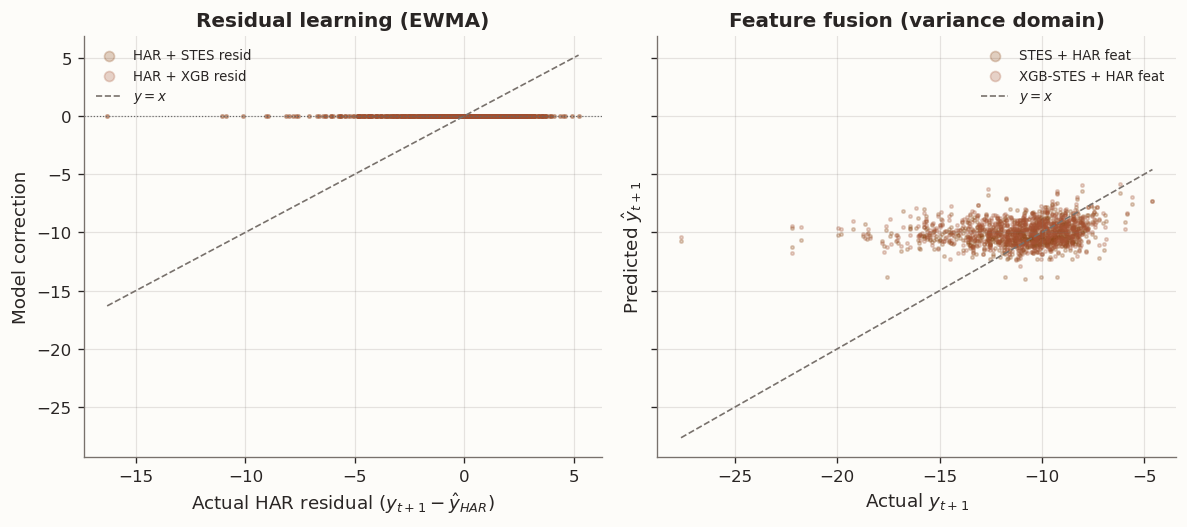

In [28]:
#| label: fig-stes-diagnostic
#| fig-cap: "Residual diagnostic: actual HAR error vs model correction"
#| code-fold: true
#| code-summary: "Diagnostic scatter"

actual_resid = y_test_actual - models_log["HAR"]  # HAR's log-domain error

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharey=True)

# Left panel: residual models (EWMA domain mismatch)
for name, color in [("HAR + STES resid", BLOG_PALETTE[0]),
                     ("HAR + XGB resid", BLOG_PALETTE[1])]:
    correction = models_log[name] - models_log["HAR"]
    axes[0].scatter(actual_resid, correction, s=4, alpha=0.25,
                    color=color, label=name, rasterized=True)
lims0 = [actual_resid.min(), actual_resid.max()]
axes[0].plot(lims0, lims0, ls="--", lw=1, color=BLOG_PALETTE[3], label="$y = x$")
axes[0].axhline(0, ls=":", lw=0.7, color=BLOG_PALETTE[4])
axes[0].set_xlabel("Actual HAR residual ($y_{t+1} - \\hat{y}_{HAR}$)")
axes[0].set_ylabel("Model correction")
axes[0].set_title("Residual learning (EWMA)")
axes[0].legend(fontsize=8, markerscale=3)

# Right panel: feature-fusion models vs HAR
for name, color in [("STES + HAR feat", BLOG_PALETTE[0]),
                     ("XGB-STES + HAR feat", BLOG_PALETTE[1])]:
    axes[1].scatter(y_test_actual, models_log[name], s=4, alpha=0.25,
                    color=color, label=name, rasterized=True)
lims1 = [y_test_actual.min(), y_test_actual.max()]
axes[1].plot(lims1, lims1, ls="--", lw=1, color=BLOG_PALETTE[3], label="$y = x$")
axes[1].set_xlabel("Actual $y_{t+1}$")
axes[1].set_ylabel("Predicted $\\hat{y}_{t+1}$")
axes[1].set_title("Feature fusion (variance domain)")
axes[1].legend(fontsize=8, markerscale=3)

fig.tight_layout()
plt.show()

### Why this fusion is principled---and where it breaks

- **HAR dominates in MSE.** Despite being a simple 3-parameter linear model, HAR (MSE $\approx 6.12$) decisively beats every variance-domain model. All STES/XGB-STES variants have *negative* OOS $R^2$ vs the unconditional mean---they are worse than predicting the training average. The log-wrapping $\hat{y} = \log(\hat{v} + \epsilon)$ compresses the EWMA forecast range (roughly $-16$ to $-8$) relative to the actual target ($-27$ to $-5$), losing extremes.

- **STES captures direction better than HAR.** A striking finding: standalone STES has the highest test-set correlation ($0.184$ vs HAR's $0.158$), despite much larger MSE. The EWMA recursion tracks directional volatility movements well; the problem is *level calibration* after domain transformation, not directional information. This suggests the variance-domain signal has value---if properly combined with a level anchor.

- **Feature fusion helps STES, not XGB-STES.** Adding HAR horizons ($x_1, x_5, x_{22}$) to the gate function reduces STES's MSE by $\sim 11\%$ (8.11 $\to$ 7.24), but barely changes XGB-STES (7.89 $\to$ 7.85). The linear gate $\alpha_t = \sigma(X_t \beta)$ benefits from explicit multi-scale information; the tree-based gate in XGB-STES already captures similar structure implicitly from the base features.

- **Residual learning adds zero.** The EWMA-based residual corrections are effectively zero (OOS $R^2$ vs HAR $= 0.0000$). The left diagnostic panel confirms this: corrections form a flat band at zero. The optimizer found that the best strategy for a non-negative recursion tracking a signed-mean-zero target is to stay near zero---exactly as predicted by the architecture constraint.

- **Does residual learning improve tail events?** No. On high-volatility days (where HAR underpredicts), the near-zero EWMA correction provides no help. On low-volatility days (where HAR overpredicts), it cannot correct downward. The nonnegativity constraint makes the EWMA structurally unable to function as a signed residual predictor.

- **Which component does "slow level" vs "surprise"?** In principle, HAR features inform *where volatility is* and the STES recursion controls *how fast to react*. In practice, both track the same slowly-moving signal (smoothed past RV), and combining two smoothers does not create the nonlinear regime-sensitivity needed to beat the unconditional mean. The higher correlation of standalone STES suggests the *directional* information exists---but extracting it requires a model that can operate natively in the log domain or combine variance-domain timing with a log-domain level anchor.

- **Bottom line.** The residual QQ plot from the HAR section (kurtosis $\approx 5.8$, skew $\approx -1.6$) shows that the errors are driven by tail events---sudden volatility spikes and drops---that neither smooth architecture can handle. Part 5 will explore regime-switching models that can change their dynamics mid-sample, and leverage-effect extensions that distinguish positive from negative return shocks.